# 03 — Classification RS / RP
Entraînement et évaluation de 3 classifieurs sur les features agrégées.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (8, 5)


## 3.1 Chargement

In [2]:
features = pd.read_parquet('../data/features.parquet')

# Encode : RS=1, RP=0
features['y'] = (features['label'] == 'RS').astype(int)

print(features['label'].value_counts())
features.head()

label
RP    285
RS    215
Name: count, dtype: int64


,conso_totale,conso_moy_jour,conso_moy_jour_actif,variance,pic_max,ratio_nuit_jour,ratio_ete_hiver,log_ratio_ete_hiver,part_ete,part_hiver,...,conso_moy_weekend,ratio_weekend_semaine,ecart_weekend_semaine,nb_jours_actifs,taux_jours_actifs,nb_jours_quasi_nuls,coeff_variation,cluster,label,y
ID,,,,,,,,,,,,,,,,,,,,,
1704875583,7380.03020,20.274808,20.274808,0.636861,4.5663,0.684167,0.229700,-1.470980,0.104003,0.453230,...,20.391255,1.008059,0.163026,364,1.000000,0,0.944662,0,RP,0
6674572658,7015.82690,19.274250,19.488408,0.809247,5.5449,0.559419,0.279000,-1.276543,0.113550,0.407357,...,19.986465,1.052508,0.997101,360,0.989011,0,1.120144,0,RP,0
9993623468,5518.24120,15.160003,17.686671,0.711909,6.7261,0.448459,0.494805,-0.703592,0.194915,0.394107,...,15.463962,1.028297,0.425542,312,0.857143,37,1.335745,1,RS,1
10607320546,6257.89815,17.192028,17.192028,0.460001,4.8466,0.509860,0.948315,-0.053069,0.217430,0.229290,...,18.432546,1.104021,1.736725,364,1.000000,0,0.946810,0,RP,0
11239534806,4834.72445,13.282210,13.282210,0.597138,5.6462,0.593209,0.177734,-1.727465,0.083589,0.471259,...,14.221172,1.101850,1.314546,364,1.000000,0,1.396296,1,RS,1


## 3.2 Équilibrage des classes + split train/test

In [3]:
rs = features[features['y'] == 1]
rp = features[features['y'] == 0]
n = min(len(rs), len(rp))

df_bal = pd.concat([
    rs.sample(n, random_state=42),
    rp.sample(n, random_state=42),
]).sample(frac=1, random_state=42)

feature_cols = [c for c in features.select_dtypes(include=[np.number]).columns
                if c not in ['cluster', 'y']]

X_raw = df_bal[feature_cols].values
y = df_bal['y'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# Pas de fuite de données : le scaler est fit uniquement sur le train.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Train : {X_train.shape[0]}  |  Test : {X_test.shape[0]}")
print(f"Features utilisées : {len(feature_cols)}")


Train : 344  |  Test : 86
Features utilisées : 22


## 3.3 Entraînement — 3 modèles

In [4]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
}

results = {}
for name, model in models.items():
    # CV sans fuite : chaque fold refit son scaler uniquement sur le train du fold.
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    cv = cross_val_score(pipe, X_train_raw, y_train, cv=5, scoring='f1').mean()

    model.fit(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    results[name] = {'model': model, 'cv_f1': cv, 'test_acc': test_acc}
    print(f"{name:25s}  CV F1: {cv:.3f}  |  Test acc: {test_acc:.3f}")


Logistic Regression        CV F1: 0.994  |  Test acc: 0.988


Random Forest              CV F1: 0.976  |  Test acc: 1.000


MLP                        CV F1: 0.994  |  Test acc: 0.988


## 3.4 Matrices de confusion

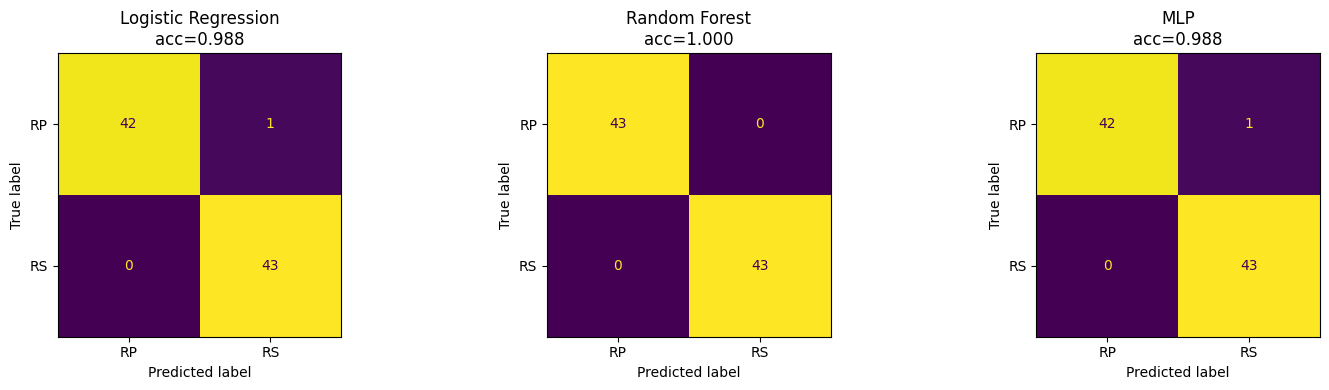

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    y_pred = res['model'].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['RP', 'RS'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{name}\nacc={res['test_acc']:.3f}")

plt.tight_layout()
plt.show()

## 3.5 Rapport détaillé du meilleur modèle

In [6]:
best_name = max(results, key=lambda k: results[k]['test_acc'])
best_model = results[best_name]['model']
y_pred_best = best_model.predict(X_test)

print(f"Meilleur modèle : {best_name}")
print(classification_report(y_test, y_pred_best, target_names=['RP', 'RS']))

Meilleur modèle : Random Forest
              precision    recall  f1-score   support

          RP       1.00      1.00      1.00        43
          RS       1.00      1.00      1.00        43

    accuracy                           1.00        86
   macro avg       1.00      1.00      1.00        86
weighted avg       1.00      1.00      1.00        86



## 3.6 Importance des features (Random Forest)

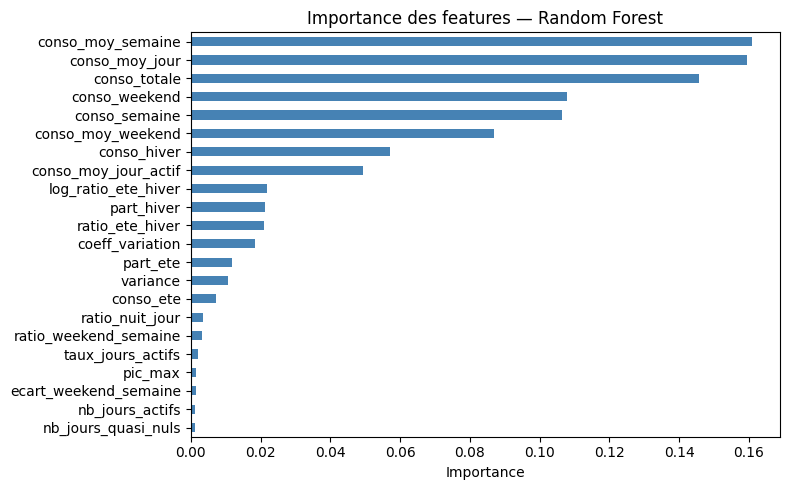

In [7]:
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Importance des features — Random Forest')
plt.tight_layout()
plt.show()

## 3.7 Sauvegarde

In [8]:
joblib.dump(best_model, '../models/classifier.pkl')
joblib.dump(scaler, '../models/scaler_clf.pkl')

with open('../models/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)

print(f"Sauvegardé : models/classifier.pkl ({best_name}), scaler_clf.pkl, feature_cols.json")


Sauvegardé : models/classifier.pkl (Random Forest), scaler_clf.pkl, feature_cols.json
